<a href="https://colab.research.google.com/github/meenakshireddy2903-cpu/DataAnalysis_Tasks/blob/main/Taxi_Trip(Linear_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trip Analysis

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#libraries related to machine learning.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("taxi_trip_pricing (1).csv")

In [3]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [5]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [15]:
df.dropna(inplace = True)

In [16]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


#EDA

In [17]:
df["Trip_Distance_km"].unique()

array([ 19.35      ,  36.87      ,   8.64      ,  41.79      ,
         9.91      ,   9.99      ,  15.91      ,  26.71      ,
        30.98      , 105.94355004,  18.95      , 138.09832791,
         3.28      ,  30.77      ,   9.36      ,  48.32      ,
        40.61      ,   5.79      ,   6.98      ,  25.26      ,
         2.69      ,  33.46      ,  26.48      ,  27.79      ,
        10.06      ,  38.98      ,  44.85      ,  30.3       ,
        46.17      ,   3.22      ,  16.94      ,  14.3       ,
        18.48      , 146.06704716,  27.59      ,   7.91      ,
        40.31      ,  38.84      ,   1.27      ,  35.64      ,
        38.79      ,   6.68      ,  43.29      ,  31.54      ,
        17.21      ,   4.11      ,  16.93      ,  36.75      ,
        44.47      ,   6.86      ,  35.95      ,  28.5       ,
        26.61      ,  21.95      ,  32.18      ,  25.92      ,
        45.47      ,  13.22      ,  21.11      , 112.83095829,
       102.74755621,  46.56      ,  40.6       ,  32.04

In [18]:
df["Time_of_Day"].unique()

array(['Morning', 'Evening', 'Afternoon', 'Night'], dtype=object)

In [19]:
df["Day_of_Week"].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [20]:
df["Passenger_Count"].unique()

array([3., 1., 2., 4.])

In [21]:
df["Traffic_Conditions"].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [22]:
df["Weather"].unique()

array(['Clear', 'Rain', 'Snow'], dtype=object)

In [23]:
df["Base_Fare"].unique()

array([3.56, 2.7 , 2.55, 4.6 , 2.32, 4.33, 4.42, 4.3 , 4.5 , 3.94, 3.38,
       2.24, 2.88, 3.64, 2.4 , 2.49, 2.31, 4.63, 3.95, 2.23, 2.15, 2.77,
       2.41, 3.16, 3.83, 4.13, 2.83, 3.92, 4.99, 2.84, 4.79, 2.07, 4.09,
       4.18, 4.93, 4.47, 3.32, 2.12, 3.09, 4.48, 4.1 , 2.17, 3.28, 2.93,
       3.58, 4.92, 3.07, 4.05, 2.95, 3.97, 3.79, 4.61, 3.35, 4.46, 2.73,
       3.26, 2.58, 4.73, 4.28, 2.27, 4.27, 2.56, 3.76, 2.05, 2.82, 2.08,
       3.88, 4.23, 4.03, 2.62, 3.06, 2.38, 2.39, 4.58, 3.85, 4.34, 4.24,
       2.86, 3.74, 2.71, 3.48, 2.64, 2.43, 3.5 , 4.74, 4.26, 4.95, 3.69,
       2.76, 4.69, 4.72, 4.9 , 2.91, 3.93, 2.59, 2.29, 4.77, 3.61, 3.89,
       2.8 , 4.67, 3.71, 4.97, 4.08, 4.02, 4.96, 3.15, 3.29, 3.31, 4.21,
       2.2 , 3.9 , 4.16, 2.44, 3.22, 2.81, 5.  , 2.63, 3.99, 4.75, 3.51,
       4.39, 2.9 , 4.45, 3.03, 4.94, 2.21, 2.36, 3.49, 4.66, 3.23, 3.81,
       3.25, 2.28, 2.96, 4.88, 4.29, 2.06, 3.37, 3.55, 4.15, 3.33, 3.77,
       4.49, 4.01, 3.46, 2.61, 3.7 , 4.4 , 3.39, 2.

In [24]:
df["Per_Km_Rate"].unique()

array([0.8 , 1.21, 1.71, 1.77, 1.26, 0.85, 1.59, 0.84, 1.69, 0.78, 1.75,
       1.76, 1.33, 1.85, 0.61, 0.88, 1.83, 1.95, 0.63, 1.25, 0.72, 1.16,
       1.28, 0.51, 1.64, 1.57, 1.63, 1.93, 0.99, 1.37, 0.73, 1.03, 1.55,
       1.34, 0.62, 1.88, 1.35, 1.82, 1.91, 1.61, 1.12, 0.79, 1.18, 0.95,
       1.78, 0.68, 1.39, 0.69, 1.9 , 1.8 , 0.87, 0.55, 0.65, 1.06, 0.67,
       1.11, 1.31, 1.73, 1.5 , 1.29, 1.01, 1.86, 1.17, 0.9 , 1.53, 0.98,
       0.77, 0.86, 1.13, 1.36, 1.84, 0.7 , 1.45, 1.48, 0.96, 1.54, 0.52,
       0.94, 1.07, 1.89, 1.66, 1.19, 1.02, 1.92, 0.76, 1.79, 1.99, 1.52,
       0.93, 0.5 , 2.  , 0.75, 0.58, 1.22, 1.2 , 0.97, 0.59, 0.83, 1.7 ,
       1.14, 1.  , 1.56, 1.96, 1.27, 1.05, 1.43, 0.74, 1.87, 1.4 , 0.53,
       1.3 , 1.94, 1.65, 0.81, 1.04, 1.24, 0.56, 1.47, 1.97, 0.82, 1.46,
       0.64, 1.72, 1.49, 1.32, 1.15, 1.41, 1.98, 1.38, 1.09, 0.57, 0.89,
       0.6 , 1.58, 0.92, 1.23, 1.44, 0.91, 1.62, 1.67, 1.42, 1.81, 0.66,
       1.51, 1.1 , 0.54, 1.74, 1.08, 0.71])

In [25]:
df["Per_Minute_Rate"].unique()

array([0.32, 0.15, 0.48, 0.11, 0.34, 0.43, 0.21, 0.2 , 0.25, 0.39, 0.13,
       0.44, 0.38, 0.24, 0.18, 0.12, 0.26, 0.29, 0.35, 0.28, 0.31, 0.42,
       0.37, 0.3 , 0.46, 0.47, 0.16, 0.1 , 0.33, 0.27, 0.17, 0.23, 0.4 ,
       0.49, 0.45, 0.14, 0.41, 0.22, 0.36, 0.19, 0.5 ])

In [26]:
df["Trip_Duration_Minutes"].unique()

array([ 53.82,  37.27,  89.33,  86.95,  41.72,  34.  , 114.93, 111.18,
        57.02,  23.03,  54.04,  94.86,  78.04, 109.6 ,   7.07,  67.25,
        42.25, 107.07,  72.37,  82.53,  97.49,  64.07,  47.97,  49.63,
        16.  ,  15.47,  52.52,  51.65,  83.15,  93.78, 100.24, 108.2 ,
       106.41,  60.81,  67.33, 110.69, 108.49,  50.21,  37.99, 104.02,
        82.93,  12.08,  36.05,  93.37, 106.78,  30.48,  59.09, 105.46,
        64.  , 102.45,   6.1 , 109.33,  65.91,  44.99,  87.13,  22.79,
        56.93,  51.92,  84.06,  78.63,  53.09, 119.21,  17.2 ,  31.8 ,
        16.24,  23.53, 119.54,  25.7 , 102.57,   7.35,  83.98,  82.54,
         9.  ,  52.06,  98.03,  97.04,  74.75,  74.49,  53.88,  66.66,
        56.65,  55.61,  87.64,  27.65,  52.47,  31.19,  72.14,  47.72,
        56.62,  28.41,  54.88,  68.73,  69.27,  34.01,  98.23,  20.63,
        21.52,   6.06,  97.94,  74.71,  43.75,  72.33,  41.3 ,  15.  ,
        64.68,  59.18,  70.94,  42.14,  32.28,  90.57,  88.21,  38.29,
      

In [27]:
df["Trip_Price"].unique()

array([ 36.2624    ,  52.9032    ,  60.2028    ,  88.1328    ,
        28.9914    ,  27.4415    ,  56.716     ,  69.0049    ,
        44.7782    , 201.86950919,  39.2366    , 280.87730155,
        24.2608    ,  58.8121    ,  20.7765    ,  61.5552    ,
        54.1018    ,  40.9225    ,  20.791     ,  57.0482    ,
        42.9921    ,  30.9982    ,  44.844     ,  44.1197    ,
        20.1596    ,  57.0766    ,  41.9343    ,  72.2695    ,
        99.8989    ,  37.1504    ,  78.715     ,  59.181     ,
        69.6575    , 320.95866358,  61.4595    ,  68.3748    ,
        71.2142    ,  69.5281    ,  11.3358    ,  36.4388    ,
       104.2421    ,  16.9284    ,  94.2463    ,  87.6076    ,
        42.8661    ,  11.2613    ,  42.9949    ,  76.2217    ,
        59.7613    ,  29.4658    ,  40.4165    , 105.9418    ,
        33.0286    ,  27.865     ,  62.4923    ,  58.7766    ,
        73.4155    ,  31.99      ,  34.3067    , 233.00828521,
       274.5350868 ,  99.8038    ,  29.532     ,  30.44

**DATA VISUALISATION**

In [28]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028
12,41.79,Night,Weekend,3.0,High,Clear,4.60,1.77,0.11,86.95,88.1328
14,9.91,Evening,Weekday,2.0,High,Clear,2.32,1.26,0.34,41.72,28.9914
...,...,...,...,...,...,...,...,...,...,...,...
990,40.17,Evening,Weekday,3.0,Low,Clear,3.81,0.66,0.42,62.66,56.6394
992,14.34,Afternoon,Weekday,1.0,Medium,Clear,3.23,1.01,0.29,45.07,30.7837
994,18.69,Evening,Weekday,3.0,Medium,Clear,4.90,1.79,0.17,79.41,51.8548
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049


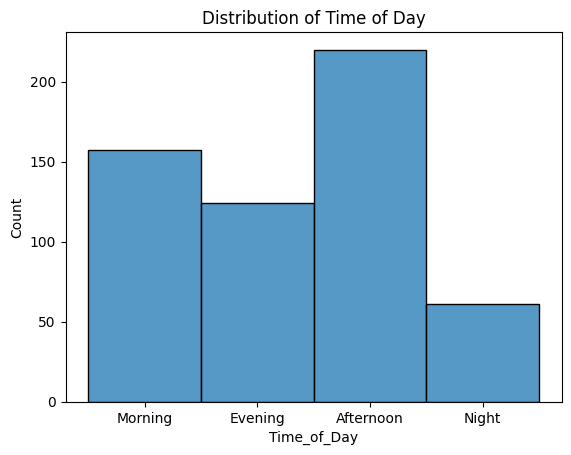

In [29]:
sns.histplot(x = "Time_of_Day",data = df)
plt.title("Distribution of Time of Day")
plt.show()

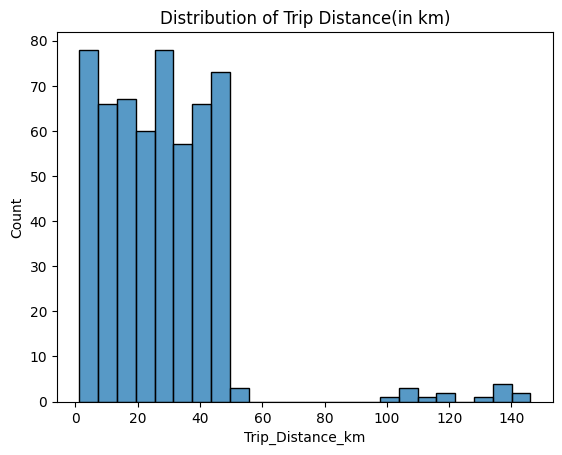

In [30]:
sns.histplot(x = "Trip_Distance_km",data = df)
plt.title("Distribution of Trip Distance(in km)")
plt.show()


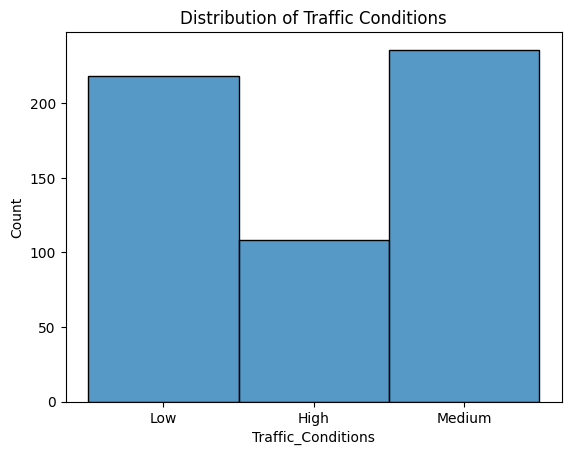

In [31]:
sns.histplot(x = "Traffic_Conditions",data = df)
plt.title("Distribution of Traffic Conditions")
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.columns:
  if df[col].dtype == object:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3.0,1,0,3.56,0.80,0.32,53.82,36.2624
2,36.87,1,1,1.0,0,0,2.70,1.21,0.15,37.27,52.9032
5,8.64,0,1,2.0,2,0,2.55,1.71,0.48,89.33,60.2028
12,41.79,3,1,3.0,0,0,4.60,1.77,0.11,86.95,88.1328
14,9.91,1,0,2.0,0,0,2.32,1.26,0.34,41.72,28.9914


<Axes: >

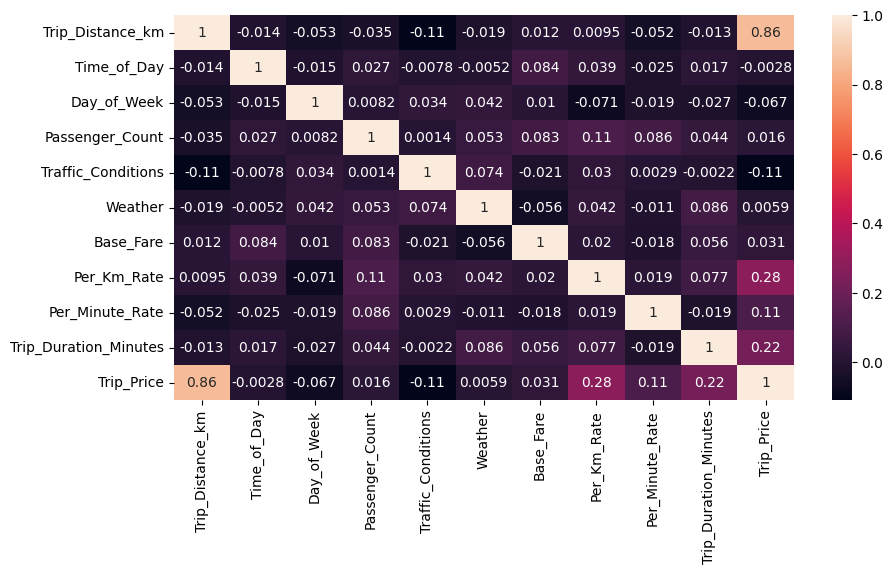

In [33]:

plt.figure(figsize = (10,5))
sns.heatmap(df.corr(),annot = True)

**Linear Regression**

In [34]:

# divide data into input and output
X = df.drop(["Trip_Price"],axis = 1)
y = df['Trip_Price']

In [35]:

# split the data into training and testing

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [36]:

# model traing
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [38]:

ypred = model.predict(Xtest)
ypred

array([ 43.83616   , 106.38323826,  45.24026425,  52.59747767,
        37.20927039,   6.34027727,  91.08905103,  38.99329061,
        61.28425053,  80.40672763,  27.56048401,  55.80679014,
        44.86929803,  65.91359002,  20.87791086,  86.60730349,
        77.79256814,  53.7579186 ,  56.59102286,  27.33805141,
        13.84287231,  36.69458119, 101.41356691,  33.09933585,
        59.92831623,  73.20963535,  61.75738119,  56.79289485,
         6.62326125,  89.04049708,  24.25948812,  53.17996201,
        76.00860731,  61.34022451,  61.65094415,  84.67001098,
        92.58104773,  48.74662756, 210.5529364 ,  12.97040372,
        49.8367864 ,  72.29433778,  89.27961986,  95.04705017,
        30.99560773,  64.17699684,  39.48227977,  51.23149958,
        63.60210152,  31.77278747,  75.32454281,  53.91357227,
        21.1993315 ,  -2.2866271 ,  51.62958842, 113.45242073,
        73.8044202 ,  20.36249628,  52.4047193 ,  73.17430935,
        62.4227979 ,  47.0733074 ,  19.68684277,  22.99

In [39]:

print("Training eff : ",model.score(Xtrain,ytrain))
print("Testing eff : ",model.score(Xtest,ytest))

Training eff :  0.8861476032033012
Testing eff :  0.8877716566927674


In [40]:
print("metrics : ")
r2 = r2_score(ytest,ypred)
print("R2 : ",r2)
N = df.shape[0]
P = df.shape[1]
adj_r2 = 1 - (((1 - r2**2)*(N-1))/N-P-1)
print("Adj r2 : ",adj_r2)
print("MSE : ",mean_squared_error(ytest,ypred))
print("MAE : ",mean_absolute_error(ytest,ypred))

metrics : 
R2 :  0.8877716566927674
Adj r2 :  12.788515492159357
MSE :  243.8802290659531
MAE :  9.663758253018695
